# Homework 09
Colaboration

---
# 8. Your turn - tasks <a id="8-your-turn"></a>

Worked solutions live in the companion notebook `01ZLMA_ex09_LLM_solutions.ipynb`, released after you have attempted the exercise.

## Theory (T*)

**T1.** Verify that for the Poisson exponential-family form (section 2.2) we have $b\prime(\theta) = e^\theta$ and $b\prime\prime(\theta) = e^\theta$. Hence the Poisson satisfies $V(\mu) = \mu$.

**T2.** Show that for the Poisson GLM with log link the IRLS working weights are $W_{ii} = \mu_i$ and the working response is $z_i = \eta_i + (y_i - \mu_i)/\mu_i$. (Use the general formulas $W_{ii} = (\mathrm{d}\mu/\mathrm{d}\eta)^2/V(\mu)$ and $z_i = \eta_i + g\prime(\mu_i)(y_i - \mu_i)$.)

**T3.** Show that for a Poisson GLM with log link and an intercept, the deviance simplifies to $D = 2 \sum_i y_i \log(y_i/\hat\mu_i)$. (Hint: the score equation for the intercept gives $\sum_i (y_i - \hat\mu_i) = 0$.)

**T4.** On smoke.csv, fit the saturated model `deaths ~ smoke * C(agecat)` with the same offset. Verify that `anova(M2, M_sat, test="Rao")` returns the Pearson $X^2 = \sum_i (y_i - \hat\mu_i)^2/\hat\mu_i$ statistic of the smaller model `M2`. (Connection: lecture-section 4.5 / Pozn at the end of section 7.4.)

**T5.** In a Poisson GLM with log link and one binary predictor $x \in \{0, 1\}$ (no offset), derive that $\exp(\beta_1) = \lambda(1) / \lambda(0)$ is the **relative risk**. Explain why this is *not* an odds ratio.

**T6.** Show that for an interaction model $\eta = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_{12} x_1 x_2$ (Poisson, log link, no offset), the relative risk of $x_1$ at $x_2 = c$ is $\exp(\beta_1 + c\beta_{12})$. Use this to re-derive the lecture-section 7.7 RR table from the Model 2 coefficients.

## Applied (A*) - smoke.csv

**A1.** Fit the Model 0 formula `deaths ~ smoke + agecat` *without* an offset; compare coefficients with the offset-aware `M0` fit in section 6. Why does it disagree, and which coefficient changes the most?

**A2.** Refit Model 2 as the saturated age-by-smoking model `deaths ~ smoke * C(agecat)` with the same offset. How does the deviance change? What does this saturated-on-age model imply about the parametric quadratic term `I(agecat**2)` and the linear `smoke:agecat` interaction?

**A3.** Compute 95 % Wald CIs for the relative risk of smoking in each age group from Model 2 (section 6.7). Add them as error bars to the RR-vs-age plot. (Hint: use the delta method on $\log \mathrm{RR}_k = \beta_\text{smoke} + k\beta_\text{smkage}$ and back-transform.)

**A4.** Compare AIC for Model 0, Model 1, Model 2. Which would AIC pick? Does AIC agree with the LRT-based decision in section 6.6?

**A5.** For Model 2, compute the expected death count for a hypothetical group of 20 000 person-years of 60-year-old non-smokers (agecat=3, smoke=0). Give a 95 % CI for the expected count: construct it on the linear-predictor scale by the delta method and back-transform to the count scale. Do not confuse this with a Poisson prediction interval for a future observed count.

## Applied (A*) - AIDS

**A6.** Fit `cases ~ t + I(t**2) + I(t**3) + I(t**4)` - does the quartic term improve the fit? Use LRT and AIC. What happens to the prediction at $t = 24$ (4 quarters past the end of data) under the cubic and quartic models?

##  Applied (A*) - Dobson

**HW1 (Insurance, Dobson 9.2.1).** Load `data/insurance.csv` (32 rows, columns `n` = number of policies, `y` = claims, `car` $\in \{1, 2, 3, 4\}$, `age` $\in \{1, 2, 3, 4\}$, `district` $\in \{0, 1\}$).

(a) Compute claim rates `y/n` and visualise them by `age`, `car`, and `district`.

(b) Treat all three predictors as categorical: fit a Poisson GLM
`y ~ C(car) + C(age) + C(district)` with `offset=np.log(insurance["n"])` (or equivalently `exposure=insurance["n"]`). Test all three two-way interactions in turn (LRT). Are any significant?

(c) Following Aitkin et al. (1989), refit with `car` and `age` as *continuous* and `district` categorical. Compare this continuous main-effects model with the categorical main-effects model from the first fit in (b) by AIC. Then discuss how the conclusion changes if you also compare with the best interaction model found in (b).



---
# 9. Summary and transition to ex10 <a id="9-summary"></a>

**What you have.** The complete machinery for fitting and interpreting a Poisson GLM: the exponential-family form (section 2), the model with offset (section 3), MLE via IRLS (section 4), the inference triangle Wald / LRT / Rao (section 5), and a fully reproduced lecture-section 7.7 example with deviance, coefficients, and per-age-group relative risks matching the printed lecture numbers (section 6). A side example on AIDS counts (section 7) clarified when an offset is essential and when it is unnecessary.

**What is next.** Exercise 10 will:

- introduce the **four residual types** for Poisson GLMs - Pearson, deviance, Anscombe, and (modern) **quantile** residuals - and show why quantile residuals are now the recommended choice;
- walk through influence diagnostics (Cook, leverage) on the smoke model;
- revisit the *continuous-vs-categorical predictor* decision on Danish lung cancer (Dunn & Smyth Ch 10) - sometimes a flexible quadratic numeric model beats a saturated factor model;
- and most importantly, address **overdispersion** - what to do when the data violate the Poisson equidispersion assumption $\mathrm{Var}(Y) = \mathbb{E}[Y]$. Two remedies are presented: **quasi-Poisson** (lecture section 7.6) which keeps the same mean structure and rescales SEs by $\sqrt{\hat\phi}$, and **Negative Binomial GLM** which gives a proper likelihood and a quadratic mean-variance relation $\mathrm{Var}(Y) = \mu + \alpha\mu^2$.



# ----------------------------------------------------------------
# T1 - T3
### Vojtěch Paleta

**T1.** Verify that for the Poisson exponential-family form (section 2.2) we have $b'(\theta) = e^\theta$ and $b''(\theta) = e^\theta$. Hence the Poisson satisfies $V(\mu) = \mu$.
Obecný předpis pro rozdělení exponenciální třídy: $$ f(y; \theta, \phi) = \exp\left\{ \frac{y\theta - b(\theta)}{a(\phi)} + c(y, \phi) \right\}. $$
Poissonovo rozdělení: $$ f(y;\mu) = \frac{\mu^y}{y!}e^{-\mu}=e^{y\ln(\mu)}e^{-\ln(y!)}e^{-\mu}=\exp\left(y \ln(\mu)-\mu-\ln(y!)\right).$$
Vidíme, že: $$\phi=1; \quad a(\phi)=1; \quad \theta = \ln(\mu); \quad b(\theta) = \mu = e^{\theta} \rightarrow b'(\theta) = e^{\theta} \rightarrow b''(\theta) = e^{\theta}; \quad V(\mu) = a(\phi)b''(\theta) = \mu.$$
**T2.** Show that for the Poisson GLM with log link the IRLS working weights are $W_{ii} = \mu_i$ and the working response is $z_i = \eta_i + (y_i - \mu_i)/\mu_i.$
 Využijeme obecných vzorců: $$W_{ii} = (\mathrm{d}\mu_i/\mathrm{d}\eta_i)^2/V(\mu_i) \quad a\quad  z_i = \eta_i + g\prime(\mu_i)(y_i - \mu_i).$$
Pro Poissonovo rozdělení s logaritmickou spojovací funkcí platí: $$ \eta_i = g(\mu_i) = \ln(\mu_i) \quad \implies \quad \mu_i = e^{\eta_i}.$$
Dosazením do výše uvedených vzorců dostaneme: $$ \begin{aligned} W_{ii} &= \frac{e^{2\eta_i}}{\mu_i} = \frac{\mu_i^2}{\mu_i} = \mu_i \\ z_i &= \eta_i + g'(\mu_i)(y_i-\mu_i) = \eta_i + \frac{y_i-\mu_i}{\mu_i}.  \end{aligned}$$
**T3.** Show that for a Poisson GLM with log link and an intercept, the deviance simplifies to $D = 2 \sum_i y_i \log(y_i/\hat\mu_i).$
Obecný předpis deviační statistiky: $$ D(\boldsymbol{y},\boldsymbol{\hat{\mu}}, \phi) = 2\left[l(\boldsymbol{\tilde{\mu}},\phi;\boldsymbol{y})-l(\boldsymbol{\hat{\mu}},\phi;\boldsymbol{y})\right],$$ kde $\boldsymbol{\tilde{\mu}}=\boldsymbol{y}$ je MLE odhad v saturovaném modelu a $\boldsymbol{\hat{\mu}}$ je MLE odhad v navrhovaném modelu.
Log-likelihood funkce Poissonova zobecněného lineárního modelu s logaritmickou spojovací funkcí má tvar: $$l(\boldsymbol{\hat{\mu}},\phi;\boldsymbol{y}) = \sum_{i=1}^n \left(y_i \ln(\hat{\mu_i}) - \mu_i - \ln(y_i!)\right) = \sum_{i=1}^n \left(y_i\left(\beta_0 + \sum_{j=1}^p \beta_j x_{ij}\right)-\exp\left(\beta_0+\sum_{j=1}^{p}\beta_j x_{ij}\right)-\ln(y_i!)\right).$$
Věrohodnostní rovnice pro parametr $\beta_0$ dává podmínku:$$\begin{aligned}\frac{\partial l}{\partial \beta_0} = \sum_{i=1}^n y_i - \sum_{i=1}^n \exp\left(\beta_0 + \sum_{j=1}^p \beta_j x_{ij}\right)&\overset{!}{=}0\\ \sum_{i=1}^n (y_i - \hat{\mu}_i)&\overset{!}{=}0. \end{aligned}$$
Po krátké úpravě deviační statistiky s využitím podmínky uvedené výše dostaneme:$$D(\boldsymbol{y},\boldsymbol{\hat{\mu}}, \phi) = 2\left[\sum_{i=1}^n\left(y_i\ln(y_i)-y_i-\ln(y_i!)\right) - \sum_{i=1}^n \left(y_i\ln(\hat{\mu}_i)-\hat{\mu}_i-\ln(y_i!)\right)\right] = 2\Bigg[\sum_{i=1}^ny_i\ln\left(\frac{y_i}{\hat{\mu}_i}\right)-\underbrace{\sum_{i=1}^n(y_i-\hat{\mu}_i)}_{=\ 0}\Bigg] = 2\sum_{i=1}^ny_i\ln\left(\frac{y_i}{\hat{\mu}_i}\right).$$

# Imports

In [66]:
import numpy as np
import pandas as pd
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy.stats import chi2, norm, poisson

import matplotlib.pyplot as plt

# helper Anova (z helpers.py z repa francji1/01ZLMA)
!curl -sL https://github.com/francji1/01ZLMA/raw/main/code/helpers.py -o helpers.py
from helpers import Anova
anova = Anova()

import io, requests, urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

BASE_URL = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/"
def load_csv(name, sep=","):
    r = requests.get(BASE_URL + name, verify=False); r.raise_for_status()
    return pd.read_csv(io.StringIO(r.text), sep=sep)

smoke = load_csv("smoke.csv", sep=";")
smoke["agecat"] = smoke["age_group"].astype("category").cat.codes + 1

# ----------------------------------------------------------------
# T4 - T6
### Krštof Blažek

In [67]:

offset_vec = np.log(smoke["person_years"])

M2 = smf.glm("deaths ~ smoke + C(agecat)", data=smoke,
              offset=offset_vec, family=sm.families.Poisson()).fit()

M_sat = smf.glm("deaths ~ smoke * C(agecat)", data=smoke,
                          offset=offset_vec, family=sm.families.Poisson()).fit()

M_sat.summary()

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 deaths   No. Observations:                   10
Model:                            GLM   Df Residuals:                        0
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -27.534
Date:                Mon, 04 May 2026   Deviance:                   3.5527e-15
Time:                        00:51:58   Pearson chi2:                 1.04e-21
No. Iterations:                     7   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -9.1479      0.707    -12.937      0.000     -10.534      -7.762
C(agecat)[T.2]           2.3574      0.764      3.087      0.002       0.860       3.854
C(agecat)[T.3]           3.8302      0.732      5.233      0.000       2.396       5.265
C(agecat)[T.4]           4.6227      0.732      6.316      0.000       3.188       6.057
C(agecat)[T.5]           5.2944      0.730      7.257      0.000       3.864       6.724
smoke                    1.7469      0.729      2.397      0.017       0.318       3.175
smoke:C(agecat)[T.2]    -0.9866      0.790     -1.249      0.212      -2.535       0.562
smoke:C(agecat)[T.3]    -1.3628      0.756     -1.802      0.072      -2.845       0.119
smoke:C(agecat)[T.4]    -1.4423      0.757     -1.906      0.057      -2.925       0.040
smoke:C(agecat)[T.5]    -1.8470      0.757     -2.439      0.015      -3.331      -0.363
========================================================================================
"""

In [68]:
M2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                 deaths   No. Observations:                   10
Model:                            GLM   Df Residuals:                        4
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -33.600
Date:                Mon, 04 May 2026   Deviance:                       12.132
Time:                        00:51:58   Pearson chi2:                     11.2
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -7.9193      0.192    -41.298      0.000      -8.295      -7.543
C(agecat)[T.2]     1.4840      0.195      7.606      0.000       1.102       1.866
C(agecat)[T.3]     2.6275      0.184     14.301      0.000       2.267       2.988
C(agecat)[T.4]     3.3505      0.185     18.130      0.000       2.988       3.713
C(agecat)[T.5]     3.7001      0.192     19.249      0.000       3.323       4.077
smoke              0.3545      0.107      3.302      0.001       0.144       0.565
==================================================================================
"""

In [69]:
anova(M2, M_sat, test="Rao")

Rao — Raova skórová statistika (Rao score test)
    T_R = U(beta_hat_0)^T * I(beta_hat_0)^{-1} * U(beta_hat_0) / phi
          ~  chi^2(p - p_0)        [phi: 1.0  (Poisson / Binomial: phi known and fixed)]
    U and I are score and EXPECTED Fisher info of the FULL model M
    evaluated at the null estimate beta_hat_0 (extended with zeros)
    aliases: Rao = score test = U^T I^{-1} U


,resid_df,resid_deviance,df,deviance,Rao,p_val
0,4,1.213237e+01,NaN,NaN,NaN,NaN
1,0,3.552713e-15,4.0,12.132366,11.155333,0.024873


In [70]:
Y = smoke["deaths"]
predicted = M2.predict()

diff = (Y-predicted)**2/predicted

summed = diff.sum()
print(summed)

11.155333197401571


In [71]:
p_value_manual = 1 - chi2.cdf(summed, 4)
print(f"Manual Rao Score Test P-value: {p_value_manual:.4e}")


Manual Rao Score Test P-value: 2.4873e-02


Ano souhlasí

## T5

$$
Y \sim \operatorname{Poisson}(\lambda(x)),
\qquad
\log \lambda(x)=\beta_0+\beta_1x.
$$

tedy

$$
\lambda(x)=\exp(\beta_0+\beta_1x).
$$

pro \(x=0\) získáme,

$$
\lambda(0)=\exp(\beta_0),
$$

a pro \(x=1\),

$$
\lambda(1)=\exp(\beta_0+\beta_1).
$$

Tedy platí

$$
\frac{\lambda(1)}{\lambda(0)}
=
\frac{\exp(\beta_0+\beta_1)}{\exp(\beta_0)}
=
\exp(\beta_1).
$$

a proto

$$
\boxed{\exp(\beta_1)=\frac{\lambda(1)}{\lambda(0)}}.
$$

Tedy platí, že $\exp(\beta_1)$ je relative rate porovnávající rate pro \(x=1\)
s rate pro \(x=0\).

To není OR, protože OR porovnává
$$
\frac{p/(1-p)\mid x=1}{p/(1-p)\mid x=0}.
$$

jenže tady ani není validních p a 1-p, co zvolit. Je tu binární vstup
x = 0 vs x = 1, ale ne binární výstup (y = 1 vs y = 0)


## T6

Uvažujeme interakční model

$$
\eta
=
\log \lambda(x_1,x_2)
=
\beta_0+\beta_1x_1+\beta_2x_2+\beta_{12}x_1x_2.
$$

Zafixujeme \(x_2=c\). Pak platí, že

$$
\log \lambda(1,c)
=
\beta_0+\beta_1+\beta_2c+\beta_{12}c,
$$

a tedy

$$
\log \lambda(0,c)
=
\beta_0+\beta_2c.
$$

Z toho máme, že

$$
\frac{\lambda(1,c)}{\lambda(0,c)}
=
\frac{
\exp(\beta_0+\beta_1+\beta_2c+\beta_{12}c)
}{
\exp(\beta_0+\beta_2c)
} =
\exp(\beta_1+\beta_{12}c).
$$

výslDek je tedy

$$
\boxed{
RR_{x_1 \mid x_2=c}
=
\exp(\beta_1+\beta_{12}c)
}.
$$



Aplikujeme-li na model z přednášky, získáme:

In [72]:
M_prednaska = smf.glm(
    "deaths ~ smoke + agecat + I(agecat**2) + smoke:agecat",
    data=smoke,
    offset=np.log(smoke["person_years"]),
    family=sm.families.Poisson()
).fit()


b = M_prednaska.params
for c in [1, 2, 3, 4, 5]:
    rr = np.exp(b["smoke"] + c * b["smoke:agecat"])
    print(c, rr)

1 3.106273555757959
2 2.2838799029470964
3 1.6792170159697541
4 1.2346401328212409
5 0.9077660856673379


# ----------------------------------------------------------------
# A1 - A5
### Vojtěch Remiš

## A1. Model 0 without offset

In [73]:
# Setup

offset_vec = np.log(smoke["person_years"])

M0 = smf.glm("deaths ~ smoke + agecat",
            data=smoke, offset=offset_vec, family=sm.families.Poisson()).fit()
M1 = smf.glm("deaths ~ smoke + agecat + I(agecat**2)",
            data=smoke, offset=offset_vec, family=sm.families.Poisson()).fit()
M2 = smf.glm("deaths ~ smoke + agecat + I(agecat**2) + smoke:agecat",
            data=smoke, offset=offset_vec, family=sm.families.Poisson()).fit()

smoke.head() # person_years = "jak velká byla populace"

,age_group,deaths,person_years,smoke,agecat
0,35 to 44,32,52407,1,1
1,45 to 54,104,43248,1,2
2,55 to 64,206,28612,1,3
3,65 to 74,186,12663,1,4
4,75 to 84,102,5317,1,5


In [74]:
# Model M0 bez offsetu
M0_no_offset = smf.glm("deaths ~ smoke + agecat",
                        data=smoke, family=sm.families.Poisson()).fit()

# 1) Porovnám oproti modelu M0 s offsetem
comparison = pd.DataFrame({
    "beta_with_offset":    M0.params,
    "beta_without_offset": M0_no_offset.params,
    "difference":          M0_no_offset.params - M0.params,
    "pct_change":          100 * (M0_no_offset.params - M0.params) / M0.params.abs(),
})

print("MODEL 0: S VS BEZ OFFSETU\n")
print(comparison.round(4))
print(f"Rozptyl s offsetem: {M0.deviance:.4f}")
print(f"Rozptyl bez offsetu: {M0_no_offset.deviance:.4f}")
print(f"\nAIC s offsetem:    {M0.aic:.4f}")
print(f"AIC bez offsetu:     {M0_no_offset.aic:.4f}")

# 2) Který koeficient se mění nejvíce?
abs_changes = np.abs(M0_no_offset.params - M0.params)
max_change_idx = np.argmax(abs_changes)
max_change_name = comparison.index[max_change_idx]
max_change_value = abs_changes.iloc[max_change_idx]

print(f"\n NEJVĚTŠÍ ZMĚNA")
print(f"Parametr: {max_change_name}")
print(f"Absolutní změna: {max_change_value:.4f}")
print(f"Relativní změna: {100 * max_change_value / M0.params.iloc[max_change_idx]:.1f}%")
print(f"  Hodnota (s offsetem): {M0.params.iloc[max_change_idx]:.4f}")
print(f"  Hodnota (bez offsetu): {M0_no_offset.params.iloc[max_change_idx]:.4f}")


MODEL 0: S VS BEZ OFFSETU

           beta_with_offset  beta_without_offset  difference  pct_change
Intercept           -8.1183               2.3451     10.4634    128.8861
smoke                0.4064               1.8306      1.4242    350.4759
agecat               0.8358               0.2062     -0.6297    -75.3341
Rozptyl s offsetem: 69.1821
Rozptyl bez offsetu: 157.5874

AIC s offsetem:    130.2500
AIC bez offsetu:     218.6553

 NEJVĚTŠÍ ZMĚNA
Parametr: Intercept
Absolutní změna: 10.4634
Relativní změna: -128.9%
  Hodnota (s offsetem): -8.1183
  Hodnota (bez offsetu): 2.3451


**Interpretace A1**
Bez offsetu model interpretuje `deaths` jako kdyby všechny buňky měly stejnou expozici, což zde neplatí (`person_years` se mezi buňkami liší řádově: ~52 000 vs ~1 500). Proto se odhadované koeficienty liší od fitu s offsetem. Nejvíce se mění **intercept** $\beta_0$ — při zahrnutí offsetu představuje log-rate (úmrtí na osobo-rok), zatímco bez offsetu představuje log počet úmrtí v "průměrné" buňce (řádově $10^2$ vs. rate řádu $10^{-3}$, tj. posun o ~$\log(10^5) \approx 11.5$). Sklon `agecat` se také výrazně mění, protože vyšší věkové kategorie mají jak méně person-years, tak více úmrtí - bez offsetu model nedokáže tyto dva efekty oddělit.

## A2. Saturovaný model `deaths ~ smoke * C(agecat)`

In [75]:
M_sat = smf.glm("deaths ~ smoke * C(agecat)", data=smoke,
                offset=offset_vec, family=sm.families.Poisson()).fit() # Všechny možné interakce věkových kategorií se smoke

tab_A2 = pd.DataFrame({
    "model":    ["M0 additive", "M1 + I(age^2)", "M2 (parametric)", "M_sat (saturated)"],
    "deviance": [M0.deviance, M1.deviance, M2.deviance, M_sat.deviance],
    "df_resid": [M0.df_resid, M1.df_resid, M2.df_resid, M_sat.df_resid],
    "AIC":      [M0.aic, M1.aic, M2.aic, M_sat.aic],
    "npar":     [M0.df_model + 1, M1.df_model + 1, M2.df_model + 1, M_sat.df_model + 1],
})
print(tab_A2.round(4))

print("\nM2 vs saturovaný (LRT)")
print(anova(M2, M_sat, test="LRT"))

               model  deviance  df_resid       AIC  npar
0        M0 additive   69.1821         7  130.2500     3
1      M1 + I(age^2)   12.1755         6   75.2435     4
2    M2 (parametric)    1.6354         5   66.7033     5
3  M_sat (saturated)    0.0000         0   75.0679    10

M2 vs saturovaný (LRT)
LRT — Likelihood Ratio Test  (Lecture 5: deviační test, statistika T_1)
    T_1 = (D_0 - D) / phi  ~  chi^2(p - p_0)        [phi: 1.0  (Poisson / Binomial: phi known and fixed)]
    aliases: LRT = chi-squared deviance test = T_1
   resid_df  resid_deviance   df  deviance      LRT     p_val
0         5    1.635370e+00  NaN       NaN      NaN       NaN
1         0    3.552713e-15  5.0   1.63537  1.63537  0.896939


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/_tools.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


**Interpretace A2**
Saturovaný model na věk x kouření má $n = 10$ pozorování a $10$ parametrů, takže `df_resid = 0` a `deviance = 0` (perfektní bodový fit). Reziduální deviance modelu M2 ($\approx 1.64$ na 5 stupních volnosti) je tedy přímo LRT statistikou pro test M2 vs saturovaný — a chí-kvadrát $p$-hodnota je velká ($p \approx 0.9$), tj. **M2 nelze zamítnout** ve prospěch saturovaného modelu.

To znamená, že kvadratický člen `I(agecat^2)` a lineární interakce `smoke:agecat`, které jsou přítomné v modelu M2, zachycují efekt věku a jeho interakci s kouřením velmi dobře - žádné silnější odchylky nebyly statisticky potvrzeny.

## A3. 95% Wald CI pro relativní riziko kouření v jednotlivých věkových skupinách
Lze ukázat, že Log relativní riziko (RR) lze  vypočítat (a dostali jsme to jako hint) jako: $\log \mathrm{RR}_k = \beta_\text{smoke} + k\beta_\text{smkage}$, kde k je věková třída a $\beta_*$ jsou parametry nafitovaného modelu.

  age_group  k     RR  SE_logRR  lower  upper
0     35-44  1  3.106     0.281  1.792  5.386
1     45-54  2  2.284     0.195  1.559  3.346
2     55-64  3  1.679     0.126  1.311  2.151
3     65-74  4  1.235     0.113  0.990  1.540
4     75-84  5  0.908     0.168  0.653  1.263


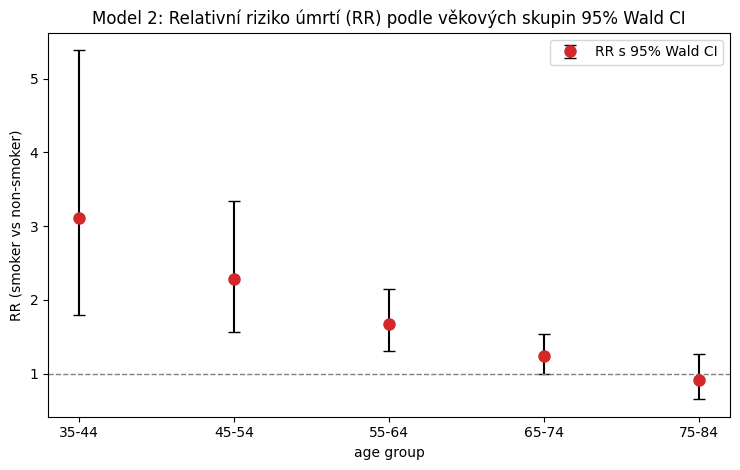

In [76]:
Sigma = M2.cov_params()
idx_s = list(M2.params.index).index("smoke") # Jaké to jsou indexy parametrů
idx_sa = list(M2.params.index).index("smoke:agecat") # Jaké to jsou indexy parametrů
z = stats.norm.ppf(0.975) # Kritická hodnota Waldova testu na hladině 5%

rows = []
for k, label in zip([1, 2, 3, 4, 5], ["35-44", "45-54", "55-64", "65-74", "75-84"]):
    a = np.zeros(len(M2.params))
    a[idx_s] = 1.0
    a[idx_sa] = k
    log_rr = a @ M2.params.values # \log \mathrm{RR}_k = \beta_\text{smoke} + k\beta_\text{smkage}
    var_log_rr = a @ Sigma.values @ a #
    se = np.sqrt(var_log_rr)
    rr = np.exp(log_rr)
    low_b = np.exp(log_rr - z * se)
    hig_b = np.exp(log_rr + z * se)
    rows.append({"age_group": label, "k": k, "RR": rr, "SE_logRR": se, "lower": low_b, "upper": hig_b})

rr_ci = pd.DataFrame(rows)
print(rr_ci.round(3))

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.errorbar(rr_ci["k"], rr_ci["RR"],
            yerr=[rr_ci["RR"] - rr_ci["lower"], rr_ci["upper"] - rr_ci["RR"]],
            fmt="o", color="tab:red", ecolor="black", capsize=4, markersize=8,
            label="RR s 95% Wald CI")
ax.axhline(1.0, color="gray", ls="--", lw=1)
ax.set_xticks(rr_ci["k"])
ax.set_xticklabels(rr_ci["age_group"])
ax.set_xlabel("age group")
ax.set_ylabel("RR (smoker vs non-smoker)")
ax.set_title("Model 2: Relativní riziko úmrtí (RR) podle věkových skupin 95% Wald CI")
ax.legend()
plt.tight_layout(); plt.show()

**Interpretace A3**
RR kouření klesá s věkem od ~3.1 (35–44 let) na ~0.91 (75–84 let). V nejstarší skupině CI obsahuje 1, takže efekt kouření tam není statisticky významný - to můžeme vysvětlit způsobem, že staří kuřáci, kteří se dožili, patří spíš do "robustnější" části populace.

## A4. AIC porovnání M0, M1, M2

In [77]:
tab_A4 = pd.DataFrame({
    "model":    ["M0 additive", "M1 + I(age^2)", "M2 + smoke:age"],
    "deviance": [M0.deviance, M1.deviance, M2.deviance],
    "df_resid": [M0.df_resid, M1.df_resid, M2.df_resid],
    "AIC":      [M0.aic, M1.aic, M2.aic],
})
tab_A4["dAIC"] = tab_A4["AIC"] - tab_A4["AIC"].min()
print(tab_A4.round(3))

best = tab_A4.loc[tab_A4["AIC"].idxmin(), "model"]
print(f"\nNejlepší dle AIC: {best}")

# Podíváme se, zda to potvrdí LRT testy
print("\n\nLRT M0 vs M1\n")
print(anova(M0, M1, test="LRT")) # Zda dává smysl přidat age^2
print("\n\nLRT M1 vs M2\ns")
print(anova(M1, M2, test="LRT")) # Zda dává smysl přidat smoke:age

            model  deviance  df_resid      AIC    dAIC
0     M0 additive    69.182         7  130.250  63.547
1   M1 + I(age^2)    12.176         6   75.243   8.540
2  M2 + smoke:age     1.635         5   66.703   0.000

Nejlepší dle AIC: M2 + smoke:age


LRT M0 vs M1

LRT — Likelihood Ratio Test  (Lecture 5: deviační test, statistika T_1)
    T_1 = (D_0 - D) / phi  ~  chi^2(p - p_0)        [phi: 1.0  (Poisson / Binomial: phi known and fixed)]
    aliases: LRT = chi-squared deviance test = T_1
   resid_df  resid_deviance   df   deviance        LRT         p_val
0         7       69.182080  NaN        NaN        NaN           NaN
1         6       12.175545  1.0  57.006535  57.006535  4.343661e-14


LRT M1 vs M2
s
LRT — Likelihood Ratio Test  (Lecture 5: deviační test, statistika T_1)
    T_1 = (D_0 - D) / phi  ~  chi^2(p - p_0)        [phi: 1.0  (Poisson / Binomial: phi known and fixed)]
    aliases: LRT = chi-squared deviance test = T_1
   resid_df  resid_deviance   df   deviance     

**Interpretace A4**
Dle AIC je nejlepší Model 2, tj. shoduje se s rozhodnutím na bázi LRT (LRT zamítá oba předchozí modely ve prospěch M2 s $p < 0.005$). Závěr: AIC i LRT volí stejný model M2.

## A5. Očekávaný počet úmrtí pro 20 000 osobo-roků 60letých nekuřáků (kategorie 3)

Nyní jsme nedostali hint, ale složení vektoru a je jednoduché:
- Intercept: 1 (vždy započítáváme základní úroveň)
- smoke: 0 (protože je to nekuřák)
- agecat: 3 (zvolený věk)
- I(agecat2): 9
- smoke:agecat: 0 (protože smoke=0, interakce mizí)

In [78]:
params = M2.params
Sigma = M2.cov_params()
names = list(params.index)

a = np.zeros(len(params))
a[names.index("Intercept")] = 1
a[names.index("smoke")] = 0
a[names.index("agecat")] = 3
a[names.index("I(agecat ** 2)")] = 9
a[names.index("smoke:agecat")] = 0

log_s = np.log(20_000)
eta_hat = a @ params.values + log_s
var_eta = a @ Sigma.values @ a # offset vynechává - nemá rozptyl
se_eta = np.sqrt(var_eta) # standartní odchylka
z = stats.norm.ppf(0.975)

mu_hat = np.exp(eta_hat)
lo = np.exp(eta_hat - z * se_eta)
hi = np.exp(eta_hat + z * se_eta)

print(f"eta_hat       = {eta_hat:.4f}")
print(f"SE(eta)       = {se_eta:.4f}")
print(f"mu_hat        = {mu_hat:.3f} předpokládaných úmrtí")
print(f"95% CI for mu = ({lo:.3f}, {hi:.3f})")

eta_hat       = 4.4621
SE(eta)       = 0.1231
mu_hat        = 86.667 předpokládaných úmrtí
95% CI for mu = (68.082, 110.325)


**Interpretace A5**
Očekávaný počet úmrtí $\hat\mu \approx 87$ s 95% Wald CI cca $(68, 110)$.

# ----------------------------------------------------------------
# A6 ...
### Ruslan Guliev

In [79]:
# Imports
aids = load_csv("aids.csv")
aids["t"] = 4 * (aids["year"] - 1984) + aids["quarter"]  # 1..20
print(aids.head())
print(f"shape: {aids.shape}")

# Try linear, quadratic, cubic in t (no offset)
A1 = smf.glm("cases ~ t", data=aids, family=sm.families.Poisson()).fit()
A2 = smf.glm("cases ~ t + I(t**2)", data=aids, family=sm.families.Poisson()).fit()
A3 = smf.glm("cases ~ t + I(t**2) + I(t**3)", data=aids, family=sm.families.Poisson()).fit()

   year  quarter  cases  t
0  1984        1      1  1
1  1984        2      6  2
2  1984        3     16  3
3  1984        4     23  4
4  1985        1     27  5
shape: (20, 4)


In [80]:
# Fit quartic model and compare with cubic (A3) via LRT and AIC
A4 = smf.glm("cases ~ t + I(t**2) + I(t**3) + I(t**4)", data=aids,
             family=sm.families.Poisson()).fit()

tab_a6 = pd.DataFrame({
    "model":    ["cubic (A3)", "quartic (A4)"],
    "deviance": [A3.deviance, A4.deviance],
    "df":       [A3.df_resid, A4.df_resid],
    "AIC":      [A3.aic,      A4.aic],
    "BIC":      [A3.bic,      A4.bic],
})
print(tab_a6.round(4).to_string(index=False))

# LRT: cubic -> quartic (1 df)
lrt_a6  = A3.deviance - A4.deviance
pval_a6 = chi2.sf(lrt_a6, 1)
print(f"LRT (cubic vs quartic): T1 = {lrt_a6:.4f}, df = 1, p = {pval_a6:.4f}")
print(f"AIC difference (cubic - quartic): {A3.aic - A4.aic:.4f}")

       model  deviance  df      AIC      BIC
  cubic (A3)   24.5393  16 144.8373 -23.3924
quartic (A4)   22.8556  15 145.1535 -22.0804
LRT (cubic vs quartic): T1 = 1.6838, df = 1, p = 0.1944
AIC difference (cubic - quartic): -0.3162


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


### Interpretace:

Podle p-val rozdíl je statisticky nevýznamný. Zlepšení deviance je o pohých 1.6838, což je navic s pravdepodobností  p = 0.1944 náhoda

 Predicted cases at t=24:
  cubic   model: 352.8
  quartic model: 153.1


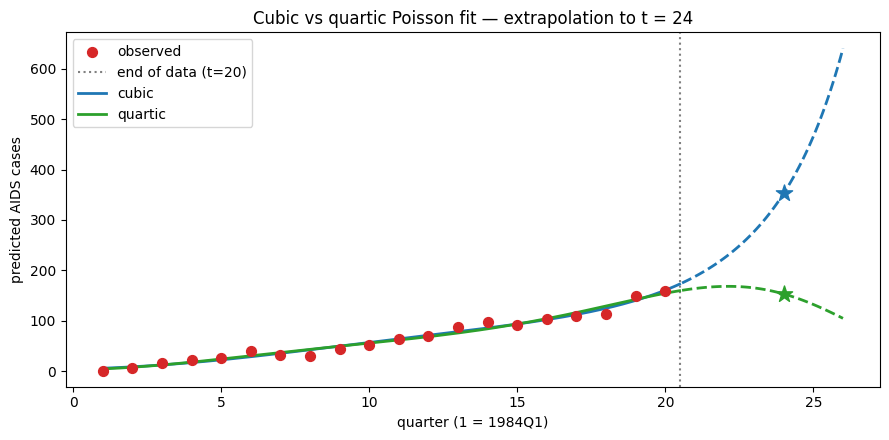

In [81]:
# Out-of-sample prediction at t = 24 (4 quarters beyond data end)
t_pred = pd.DataFrame({'t': [24]})

pred_cubic   = A3.predict(t_pred).iloc[0]
pred_quartic = A4.predict(t_pred).iloc[0]
print(f" Predicted cases at t=24:")
print(f"  cubic   model: {pred_cubic:.1f}")
print(f"  quartic model: {pred_quartic:.1f}")

# Plot both models with extrapolation to t=24
t_grid = np.linspace(1, 26, 300)
df_grid = pd.DataFrame({'t': t_grid})

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(aids['t'], aids['cases'], color='tab:red', s=50, zorder=5, label='observed')
ax.axvline(20.5, color='gray', ls=':', lw=1.5, label='end of data (t=20)')

for label, m, color in [('cubic', A3, 'tab:blue'), ('quartic', A4, 'tab:green')]:
    fitted = m.predict(df_grid)
    ax.plot(t_grid[t_grid <= 20.5], fitted[t_grid <= 20.5], color=color, lw=2, label=label)
    ax.plot(t_grid[t_grid >= 20.5], fitted[t_grid >= 20.5], color=color, lw=2, ls='--')
    ax.scatter([24], [m.predict(t_pred).iloc[0]], color=color, marker='*', s=150, zorder=6)

ax.set_xlabel('quarter (1 = 1984Q1)')
ax.set_ylabel('predicted AIDS cases')
ax.set_title('Cubic vs quartic Poisson fit — extrapolation to t = 24')
ax.legend(); plt.tight_layout(); plt.show()

### Interpretace:
Oba modely se na existujících historických datech naučily téměř totéž. V oblasti extrapolace polynom 4. stupně úplně selhává.

In [82]:
insurance = load_csv("insurance.csv")
insurance["rate"] = insurance["y"] / insurance["n"]
print(insurance.head(10))
print(f"shape: {insurance.shape}")

M = smf.glm(
    "y ~ car + age + C(district)",
    data=insurance,
    offset=np.log(insurance["n"]),   # ← toto chybí
    family=sm.families.Poisson()
).fit()
print("Main-effects (categorical):")
print(f"  deviance = {M.deviance:.4f},  df = {M.df_resid},  AIC = {M.aic:.4f}, BIC = {M.bic:.4f}")

   car  age  district    n   y      rate
0    1    1         0  197  38  0.192893
1    1    1         1  264  35  0.132576
2    1    2         0  264  38  0.143939
3    1    2         1  365  20  0.054795
4    1    3         0  246  28  0.113821
5    1    3         1  300  20  0.066667
6    1    4         0  133   4  0.030075
7    1    4         1  149   3  0.020134
8    2    1         0  284  63  0.221831
9    2    1         1  536  84  0.156716
shape: (32, 6)
Main-effects (categorical):
  deviance = 63.8758,  df = 28,  AIC = 192.6230, BIC = -33.1648


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


### (a) Vykreslování závislostí mezi `age`, `car`, a `district`

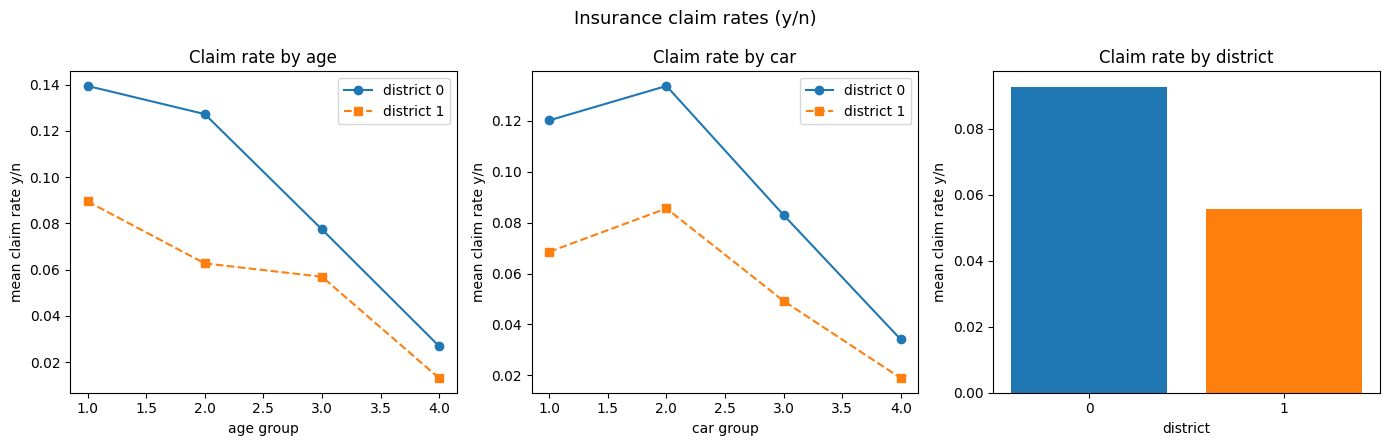

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# by age
for dist, ls, lbl in [(0, "-o", "district 0"), (1, "--s", "district 1")]:
    sub = insurance[insurance["district"] == dist].groupby("age")["rate"].mean()
    axes[0].plot(sub.index, sub.values, ls, label=lbl)
axes[0].set_xlabel("age group"); axes[0].set_ylabel("mean claim rate y/n")
axes[0].set_title("Claim rate by age"); axes[0].legend()

# by car
for dist, ls, lbl in [(0, "-o", "district 0"), (1, "--s", "district 1")]:
    sub = insurance[insurance["district"] == dist].groupby("car")["rate"].mean()
    axes[1].plot(sub.index, sub.values, ls, label=lbl)
axes[1].set_xlabel("car group"); axes[1].set_ylabel("mean claim rate y/n")
axes[1].set_title("Claim rate by car"); axes[1].legend()

# by district
ins_d = insurance.groupby("district")["rate"].mean()
axes[2].bar(ins_d.index.astype(str), ins_d.values, color=["tab:blue", "tab:orange"])
axes[2].set_xlabel("district"); axes[2].set_ylabel("mean claim rate y/n")
axes[2].set_title("Claim rate by district")

plt.suptitle("Insurance claim rates (y/n)", fontsize=13)
plt.tight_layout(); plt.show()

### Interprateace

Čteme grafy zleva:

1. Čím vyšší je věková skupina řidiče (od 1 do 4), tím nižší je průměrné riziko nehody. Mladí řidiči (skupina 1) bourají a hlásí škody výrazně častěji než starší a zkušenější řidiči (skupina 4).
2. Vliv typu auta není lineární (křivka netvoří rovnou přímku dolů ani nahoru, dělá takovou "stříšku"). Nejrizikovější jsou auta ve skupině 2, následovaná skupinou 1, pak 3 a nejméně riziková je skupina 4.
3. Lidé z okresu 0 bourají podstatně častěji (jizni cechy).



### (b) Poissonovská regrese s kategorickými prediktory, test interakcí
Baseline model: `y ~ C(car) + C(age) + C(district)` s offsetem log(n).

In [63]:
off_ins = np.log(insurance["n"])

# Main-effects model (categorical)
M_cat = smf.glm(
    "y ~ C(car) + C(age) + C(district)",
    data=insurance, offset=off_ins, family=sm.families.Poisson()).fit()
print("Main-effects (categorical):")
print(f"  deviance = {M_cat.deviance:.4f},  df = {M_cat.df_resid},  AIC = {M_cat.aic:.4f}, BIC = {M_cat.bic:.4f}")

# Three two-way interaction models
interactions = [
    ("car × age",      "y ~ C(car)*C(age) + C(district)"),
    ("car × district", "y ~ C(car)*C(district) + C(age)"),
    ("age × district", "y ~ C(car) + C(age)*C(district)"),
]
print(f"{"Interaction":<20}  {"deviance":>10}  {"df":>4}  {"LRT":>8}  {"p-value":>10}")
print("-" * 60)
for label, formula in interactions:
    m = smf.glm(formula, data=insurance, offset=off_ins, family=sm.families.Poisson()).fit()
    lrt = M_cat.deviance - m.deviance
    df_diff = int(M_cat.df_resid - m.df_resid)
    pval = chi2.sf(lrt, df_diff)
    print(f"{label:<20}  {m.deviance:10.4f}  {m.df_resid:4.0f}  {lrt:8.4f}  {pval:10.4f}")

Main-effects (categorical):
  deviance = 35.5307,  df = 24,  AIC = 172.2778, BIC = -47.6470
Interaction             deviance    df       LRT     p-value
------------------------------------------------------------
car × age                16.1271    15   19.4035      0.0220
car × district           33.7219    21    1.8088      0.6130
age × district           32.3505    21    3.1802      0.3647


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


### Finální model s přidáním interakce car:age


In [64]:
M_final = smf.glm(
    "y ~ C(car)*C(age) + C(district)",
    data=insurance, offset=off_ins, family=sm.families.Poisson()
).fit()

print("Final model: C(car)*C(age) + C(district)")
print(f"  deviance = {M_final.deviance:.4f},  df = {M_final.df_resid},  AIC = {M_final.aic:.4f}, BIC = {M_final.bic:.4f}")

# LRT: final vs main-effects
lrt = M_cat.deviance - M_final.deviance
df_diff = int(M_cat.df_resid - M_final.df_resid)
pval = chi2.sf(lrt, df_diff)
print(f"  LRT vs main-effects: T1 = {lrt:.4f}, df = {df_diff}, p = {pval:.4f}")

# AIC comparison
tab = pd.DataFrame({
    "model": ["main-effects (categorical)", "+ C(car)*C(age)"],
    "deviance": [M_cat.deviance, M_final.deviance],
    "df_resid": [M_cat.df_resid, M_final.df_resid],
    "AIC":      [M_cat.aic, M_final.aic],
    "BIC":      [M_cat.bic, M_final.bic],
})
print()
print(tab.round(4).to_string(index=False))



Final model: C(car)*C(age) + C(district)
  deviance = 16.1271,  df = 15,  AIC = 170.8743, BIC = -35.8589
  LRT vs main-effects: T1 = 19.4035, df = 9, p = 0.0220

                     model  deviance  df_resid      AIC      BIC
main-effects (categorical)   35.5307        24 172.2778 -47.6470
           + C(car)*C(age)   16.1271        15 170.8743 -35.8589


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1923: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


### (c) Spojitén`car`, `age` a kategorické  `district`


In [65]:
# Continuous main-effects model
M_cont = smf.glm(
    "y ~ car + age + C(district)",
    data=insurance, offset=off_ins, family=sm.families.Poisson()
).fit()

# Best interaction model from (b): find minimum deviance
int_models = {}
for label, formula in interactions:
    int_models[label] = smf.glm(formula, data=insurance, offset=off_ins,
                                 family=sm.families.Poisson()).fit()

best_label = min(int_models, key=lambda k: int_models[k].aic)
M_best_int = int_models[best_label]

comp = pd.DataFrame({
    "model": ["categorical main-effects", "continuous main-effects",
              f"best interaction ({best_label})"],
    "deviance": [M_cat.deviance, M_cont.deviance, M_best_int.deviance],
    "df_resid": [M_cat.df_resid, M_cont.df_resid, M_best_int.df_resid],
    "AIC":      [M_cat.aic, M_cont.aic, M_best_int.aic],
})
print(comp.round(4))

print("Continuous main-effects model coefficients:")
print(M_cont.params.round(4))

print("Conclusion:")
aic_diff = M_cat.aic - M_cont.aic
print(f"  AIC(categorical) - AIC(continuous) = {aic_diff:.2f}")
if aic_diff > 2:
    print("  Continuous model is preferred by AIC (more parsimonious with lower AIC).")
elif aic_diff < -2:
    print("  Categorical model is preferred by AIC.")
else:
    print("  Models are comparable by AIC (delta < 2).")
print(f"vs. best interaction model ({best_label}): AIC = {M_best_int.aic:.4f}")
print(f"  AIC(continuous) - AIC(best interaction) = {M_cont.aic - M_best_int.aic:.2f}")

                          model  deviance  df_resid       AIC
0      categorical main-effects   35.5307        24  172.2778
1       continuous main-effects   63.8758        28  192.6230
2  best interaction (car × age)   16.1271        15  170.8743
Continuous main-effects model coefficients:
Intercept          -0.9090
C(district)[T.1]   -0.4892
car                -0.1625
age                -0.4016
dtype: float64
Conclusion:
  AIC(categorical) - AIC(continuous) = -20.35
  Categorical model is preferred by AIC.
vs. best interaction model (car × age): AIC = 170.8743
  AIC(continuous) - AIC(best interaction) = 21.75


### Interpretace

Po tom, co jsme řekli modelu, že proměnné jsou spojité veličiny, došlo ke zhoršení statistik. Pro tato konkrétní data kategoriální proměnné jsou jasnou volbou.